In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu, shapiro, ttest_ind

candidate_base_dirs = [Path.cwd(), *Path.cwd().parents]
base_dir = next((p for p in candidate_base_dirs if (p / "HDF files").exists()), Path.cwd())
hdf_dir = base_dir / "HDF files"
results_dir = base_dir / "Notebooks"

group_order = ["control", "rbd"]
stage_order = ["Wake", "N1", "N2", "N3", "REM"]
palette = {"control": "#4C78A8", "rbd": "#E45756"}

sns.set_theme(style="whitegrid", context="notebook")
print(f"Using HDF folder: {hdf_dir}")


def read_value(node):
    value = node[()]
    if isinstance(value, bytes):
        return value.decode("utf-8")
    if isinstance(value, np.generic):
        return value.item()
    return value


def maybe_read(group, key):
    return read_value(group[key]) if key in group else np.nan


def load_h5_summaries(hdf_dir: Path):
    patient_rows = []
    epoch_rows = []

    for h5_path in sorted(hdf_dir.glob("*.h5")):
        try:
            with h5py.File(h5_path, "r") as f:
                if len(f.keys()) == 0:
                    print(f"Skipping empty file: {h5_path.name}")
                    continue

                patient_id = next(iter(f.keys()))
                patient = f[patient_id]
                group = str(patient.attrs.get("group", "unknown")).lower()

                patient_row = {
                    "patient_id": patient_id,
                    "group": group,
                    "n_epochs_all": maybe_read(patient, "n_epochs_all"),
                    "n_epochs_rem": maybe_read(patient, "n_epochs_rem"),
                    "n_epochs_nrem": maybe_read(patient, "n_epochs_nrem"),
                    "n_valid_hep_epochs": maybe_read(patient, "n_valid_hep_epochs"),
                    "mean_delta_power_all": maybe_read(patient, "mean_delta_power_all"),
                    "mean_delta_power_REM": maybe_read(patient, "mean_delta_power_REM"),
                    "mean_delta_power_NREM": maybe_read(patient, "mean_delta_power_NREM"),
                    "mean_hep_all": maybe_read(patient, "mean_hep_all"),
                    "mean_hep_REM": maybe_read(patient, "mean_hep_REM"),
                    "mean_hep_NREM": maybe_read(patient, "mean_hep_NREM"),
                }

                if "hep_waveform_derived" in patient:
                    wf = patient["hep_waveform_derived"]
                    for key in [
                        "hep_peak_latency_all",
                        "hep_peak_latency_REM",
                        "hep_peak_latency_NREM",
                        "hep_auc_all",
                        "hep_auc_REM",
                        "hep_auc_NREM",
                    ]:
                        patient_row[key] = maybe_read(wf, key)

                if "correlations" in patient:
                    corr = patient["correlations"]
                    for key in corr.keys():
                        patient_row[key] = read_value(corr[key])

                patient_rows.append(patient_row)

                if "epochs" not in patient:
                    continue

                for epoch_name, epoch in patient["epochs"].items():
                    epoch_rows.append(
                        {
                            "patient_id": patient_id,
                            "group": group,
                            "epoch": epoch_name,
                            "stage": read_value(epoch["sleep_stage"]),
                            "delta": read_value(epoch["eeg_bandpower"]["delta"]),
                            "theta": read_value(epoch["eeg_bandpower"]["theta"]),
                            "alpha": read_value(epoch["eeg_bandpower"]["alpha"]),
                            "beta": read_value(epoch["eeg_bandpower"]["beta"]),
                            "gamma": read_value(epoch["eeg_bandpower"]["gamma"]),
                            "hr_mean_bpm": read_value(epoch["hrv"]["hr_mean_bpm"]),
                            "rmssd_ms": read_value(epoch["hrv"]["rmssd_ms"]),
                            "sdnn_ms": read_value(epoch["hrv"]["sdnn_ms"]),
                            "pnn50_pct": read_value(epoch["hrv"]["pnn50_pct"]),
                            "hfc": read_value(epoch["cpc"]["hfc"]),
                            "lfc": read_value(epoch["cpc"]["lfc"]),
                            "cpc_ratio": read_value(epoch["cpc"]["ratio"]),
                            "pearson_1s_r": read_value(epoch["hep"]["pearson_1s_r"]),
                            "spearman_1s_r": read_value(epoch["hep"]["spearman_1s_r"]),
                            "hep_30s": read_value(epoch["hep"]["hep_30s"]),
                            "delta_30s": read_value(epoch["hep"]["delta_30s"]),
                        }
                    )
        except OSError as exc:
            print(f"Skipping {h5_path.name}: {exc}")

    patient_df = pd.DataFrame(patient_rows)
    if not patient_df.empty:
        patient_df = patient_df.sort_values(["group", "patient_id"]).reset_index(drop=True)

    epoch_df = pd.DataFrame(epoch_rows)
    if not epoch_df.empty:
        epoch_df["stage"] = pd.Categorical(epoch_df["stage"], categories=stage_order, ordered=True)
        numeric_cols = [
            "delta",
            "theta",
            "alpha",
            "beta",
            "gamma",
            "hr_mean_bpm",
            "rmssd_ms",
            "sdnn_ms",
            "pnn50_pct",
            "hfc",
            "lfc",
            "cpc_ratio",
            "pearson_1s_r",
            "spearman_1s_r",
            "hep_30s",
            "delta_30s",
        ]
        stage_df = (
            epoch_df.groupby(["patient_id", "group", "stage"], observed=True)[numeric_cols]
            .mean(numeric_only=True)
            .reset_index()
        )
    else:
        stage_df = pd.DataFrame()

    return patient_df, stage_df, epoch_df


def cohen_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx = len(x)
    ny = len(y)
    if nx < 2 or ny < 2:
        return np.nan
    sx = np.nanstd(x, ddof=1)
    sy = np.nanstd(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if pooled == 0 or not np.isfinite(pooled):
        return np.nan
    return (np.nanmean(x) - np.nanmean(y)) / pooled


def rank_biserial_from_u(u_stat, n1, n2):
    if n1 == 0 or n2 == 0:
        return np.nan
    return 1 - (2 * u_stat) / (n1 * n2)


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan, dtype=float)
    finite = np.isfinite(p_values)
    if not finite.any():
        return adjusted

    p = p_values[finite]
    order = np.argsort(p)
    ranked = p[order]
    n = len(ranked)
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    adjusted_finite = np.empty_like(p)
    adjusted_finite[order] = q
    adjusted[finite] = adjusted_finite
    return adjusted


def compare_groups(df, metric, group_col="group"):
    subset = df[[group_col, metric]].dropna().copy()
    control = subset.loc[subset[group_col] == "control", metric].astype(float)
    rbd = subset.loc[subset[group_col] == "rbd", metric].astype(float)

    row = {
        "metric": metric,
        "n_control": int(control.shape[0]),
        "n_rbd": int(rbd.shape[0]),
        "mean_control": control.mean(),
        "mean_rbd": rbd.mean(),
        "median_control": control.median(),
        "median_rbd": rbd.median(),
        "sd_control": control.std(ddof=1),
        "sd_rbd": rbd.std(ddof=1),
    }

    if len(control) < 3 or len(rbd) < 3:
        row.update(
            {
                "test": "insufficient_n",
                "statistic": np.nan,
                "p_value": np.nan,
                "effect_size": np.nan,
                "effect_name": np.nan,
                "shapiro_control_p": np.nan,
                "shapiro_rbd_p": np.nan,
            }
        )
        return row

    shapiro_control_p = shapiro(control).pvalue
    shapiro_rbd_p = shapiro(rbd).pvalue
    use_t_test = (shapiro_control_p > 0.05) and (shapiro_rbd_p > 0.05)

    if use_t_test:
        stat, p_value = ttest_ind(control, rbd, equal_var=False, nan_policy="omit")
        effect_size = cohen_d(control, rbd)
        effect_name = "cohen_d"
        test_name = "welch_t"
    else:
        stat, p_value = mannwhitneyu(control, rbd, alternative="two-sided")
        effect_size = rank_biserial_from_u(stat, len(control), len(rbd))
        effect_name = "rank_biserial"
        test_name = "mann_whitney"

    row.update(
        {
            "test": test_name,
            "statistic": stat,
            "p_value": p_value,
            "effect_size": effect_size,
            "effect_name": effect_name,
            "shapiro_control_p": shapiro_control_p,
            "shapiro_rbd_p": shapiro_rbd_p,
        }
    )
    return row


def run_stats_table(df, metrics, group_col="group"):
    stats_df = pd.DataFrame(compare_groups(df, metric, group_col=group_col) for metric in metrics)
    stats_df["p_fdr_bh"] = benjamini_hochberg(stats_df["p_value"].to_numpy(dtype=float))
    return stats_df.sort_values("p_value", na_position="last").reset_index(drop=True)


def stage_stats_table(stage_df, metric):
    rows = []
    for stage in stage_order:
        stage_subset = stage_df.loc[stage_df["stage"] == stage].copy()
        if stage_subset.empty:
            continue
        row = compare_groups(stage_subset, metric)
        row["stage"] = stage
        rows.append(row)

    stats_df = pd.DataFrame(rows)
    if not stats_df.empty:
        stats_df["p_fdr_bh"] = benjamini_hochberg(stats_df["p_value"].to_numpy(dtype=float))
    return stats_df


def plot_metric(df, metric, title=None, ylabel=None, group_col="group"):
    plot_df = df[[group_col, metric]].dropna().copy()
    if plot_df.empty:
        print(f"No data available for {metric}")
        return

    stats_row = compare_groups(df, metric, group_col=group_col)

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)
    sns.stripplot(data=plot_df, x=group_col, y=metric, order=group_order, color="black", alpha=0.7, jitter=0.12, size=6)
    plt.title(title or metric)
    plt.xlabel("")
    plt.ylabel(ylabel or metric)
    plt.grid(axis="y", alpha=0.25)

    if pd.notna(stats_row["p_value"]):
        plt.suptitle(
            f"{stats_row['test']} | p={stats_row['p_value']:.3g} | effect={stats_row['effect_size']:.3g}",
            y=0.98,
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()


def plot_stage_metric(stage_df, metric, title=None, ylabel=None):
    plot_df = stage_df[["patient_id", "group", "stage", metric]].dropna().copy()
    if plot_df.empty:
        print(f"No stage data available for {metric}")
        return

    ax = plt.figure(figsize=(10, 4)).gca()
    sns.boxplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, palette=palette, showfliers=False, ax=ax)
    sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[: len(group_order)], labels[: len(group_order)], title="group", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(title or f"{metric} by stage")
    ax.set_xlabel("Sleep stage")
    ax.set_ylabel(ylabel or metric)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


Using HDF folder: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\HDF files


Patients loaded: 30
group
control    15
rbd        15
Name: count, dtype: int64


,patient_id,group,n_epochs_all,n_valid_hep_epochs
0,ins1,control,906,906
1,ins2,control,1675,1675
2,ins3,control,856,856
3,ins4,control,718,718
4,ins5,control,1720,1716
5,ins6,control,1057,1057
6,ins7,control,1483,1482
7,ins8,control,833,833
8,ins9,control,1050,1050
9,n01,control,1140,1139


,metric,n_control,n_rbd,mean_control,mean_rbd,median_control,median_rbd,sd_control,sd_rbd,test,statistic,p_value,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,p_fdr_bh
0,mean_hep_NREM,15,15,3.4877,2.8049,3.0954,2.2588,1.3601,2.5241,mann_whitney,172.0000,0.0144,-0.5289,rank_biserial,0.0224,0.0000,0.1004
1,mean_hep_REM,15,15,3.1398,2.5382,2.4328,1.9059,1.4387,2.5351,mann_whitney,167.0000,0.0251,-0.4844,rank_biserial,0.0134,0.0000,0.1004
2,pearson_30s_r_NREM,15,15,0.2724,0.1965,0.3269,0.2063,0.1597,0.1681,welch_t,1.2681,0.2152,0.4631,cohen_d,0.5092,0.1023,0.5329
3,mean_delta_power_NREM,15,15,0.4373,0.4011,0.4246,0.3954,0.0897,0.0850,welch_t,1.1340,0.2664,0.4141,cohen_d,0.8560,0.4511,0.5329
4,hep_auc_REM,15,15,0.0421,0.0302,0.0621,0.0583,0.1184,0.1142,welch_t,0.2811,0.7807,0.1026,cohen_d,0.4922,0.1701,0.9669
5,pearson_30s_r_REM,15,15,0.1972,0.2155,0.1444,0.2964,0.1805,0.1838,welch_t,-0.2752,0.7851,-0.1005,cohen_d,0.1764,0.1210,0.9669
6,hep_auc_NREM,15,15,0.0299,0.0426,0.0615,0.0534,0.1160,0.1010,mann_whitney,108.0000,0.8682,0.0400,rank_biserial,0.0323,0.3673,0.9669
7,mean_delta_power_REM,15,15,0.3871,0.3674,0.3621,0.3835,0.1429,0.1102,mann_whitney,114.0000,0.9669,-0.0133,rank_biserial,0.0414,0.6067,0.9669


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_patient_level_results.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


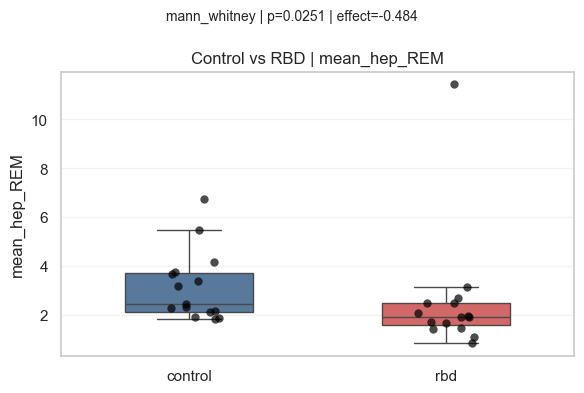

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


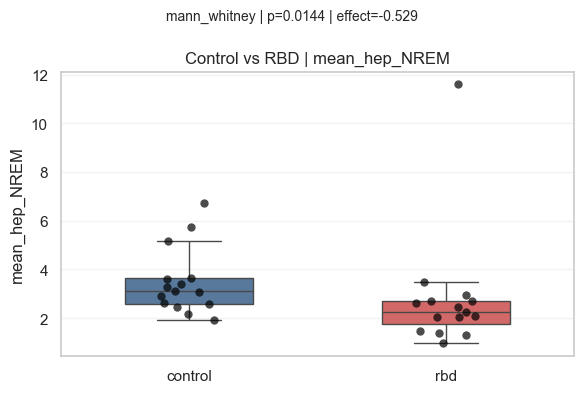

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


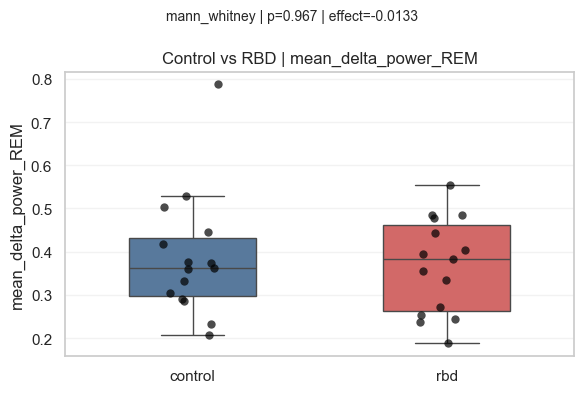

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


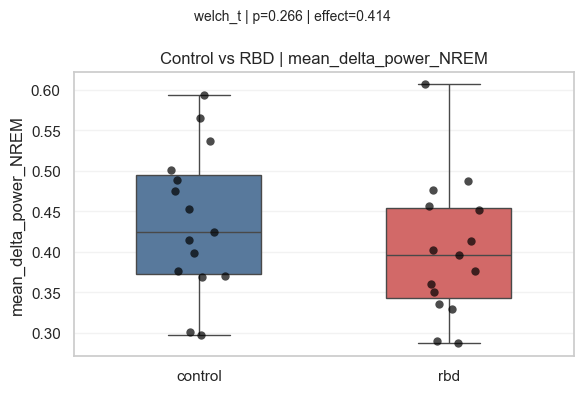

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


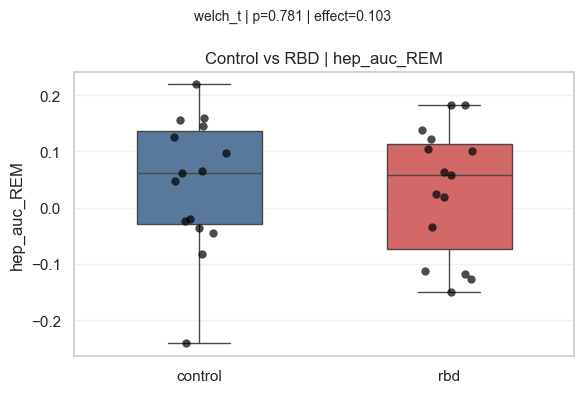

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


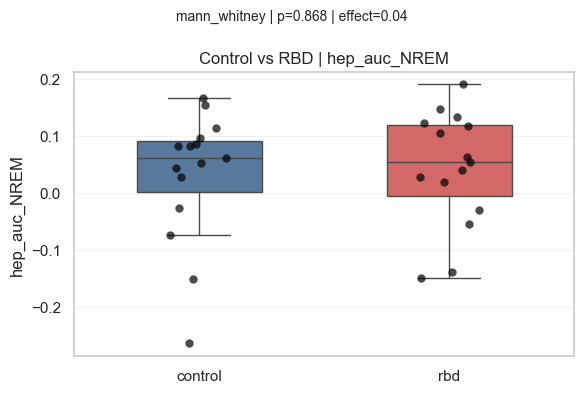

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


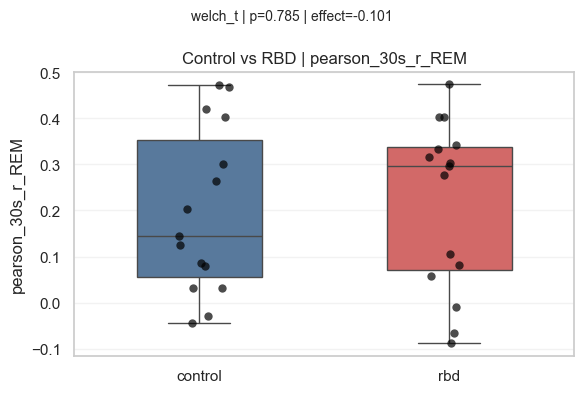

C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:286: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=group_col, y=metric, order=group_order, palette=palette, showfliers=False, width=0.5)


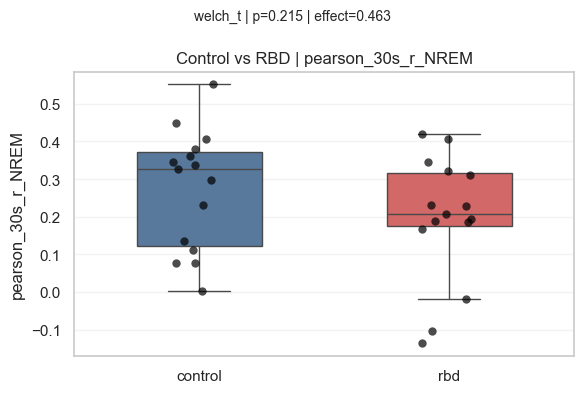

In [2]:
patient_df, stage_df, epoch_df = load_h5_summaries(hdf_dir)

print(f"Patients loaded: {len(patient_df)}")
print(patient_df["group"].value_counts(dropna=False))
display(patient_df[["patient_id", "group", "n_epochs_all", "n_valid_hep_epochs"]].sort_values(["group", "patient_id"]))

# Important: the group test is done on one summary value per patient, not per epoch.
patient_metrics = [
    "mean_hep_REM",
    "mean_hep_NREM",
    "mean_delta_power_REM",
    "mean_delta_power_NREM",
    "hep_auc_REM",
    "hep_auc_NREM",
    "pearson_30s_r_REM",
    "pearson_30s_r_NREM",
]

stats_patient = run_stats_table(patient_df, patient_metrics)
display(stats_patient.round(4))

patient_csv = results_dir / "statistics_patient_level_results.csv"
stats_patient.to_csv(patient_csv, index=False)
print(f"Saved: {patient_csv}")

for metric in patient_metrics:
    plot_metric(patient_df, metric, title=f"Control vs RBD | {metric}")



Stage-level comparison for hep_30s


,stage,metric,test,n_control,n_rbd,mean_control,mean_rbd,p_value,p_fdr_bh,effect_size
0,Wake,hep_30s,mann_whitney,15,15,4.0602,3.0402,0.0465,0.0620,-0.4311
1,N1,hep_30s,mann_whitney,15,15,3.5680,2.9867,0.0512,0.0620,-0.4222
2,N2,hep_30s,mann_whitney,15,15,3.2837,2.7013,0.0620,0.0620,-0.4044
3,N3,hep_30s,mann_whitney,15,15,3.8396,3.0078,0.0090,0.0449,-0.5644
4,REM,hep_30s,mann_whitney,15,15,3.1398,2.5382,0.0251,0.0620,-0.4844


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_hep_30s.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:312: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


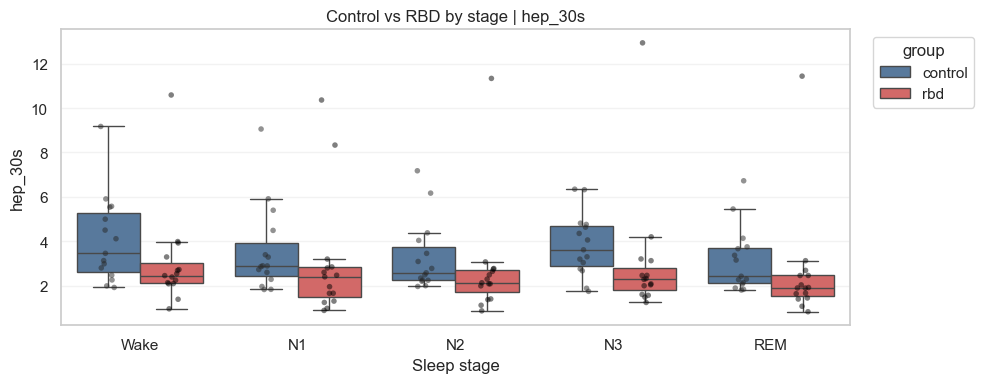


Stage-level comparison for delta_30s


,stage,metric,test,n_control,n_rbd,mean_control,mean_rbd,p_value,p_fdr_bh,effect_size
0,Wake,delta_30s,welch_t,15,15,0.3975,0.3108,0.0627,0.1570,0.7081
1,N1,delta_30s,welch_t,15,15,0.3571,0.2669,0.0942,0.1570,0.6358
2,N2,delta_30s,welch_t,15,15,0.4224,0.3679,0.0829,0.1570,0.6579
3,N3,delta_30s,welch_t,15,15,0.4798,0.4720,0.8252,0.9669,0.0814
4,REM,delta_30s,mann_whitney,15,15,0.3871,0.3674,0.9669,0.9669,-0.0133


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_delta_30s.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:312: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


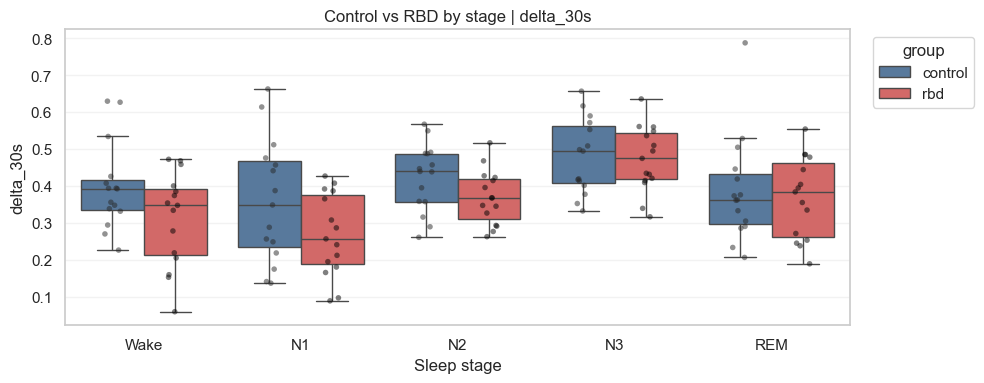


Stage-level comparison for cpc_ratio


,stage,metric,test,n_control,n_rbd,mean_control,mean_rbd,p_value,p_fdr_bh,effect_size
0,Wake,cpc_ratio,mann_whitney,15,15,0.2888,0.2333,0.5069,0.5614,-0.1467
1,N1,cpc_ratio,mann_whitney,15,15,0.2588,0.2530,0.1057,0.2641,-0.3511
2,N2,cpc_ratio,mann_whitney,15,15,0.2697,0.2326,0.1585,0.2641,-0.3067
3,N3,cpc_ratio,mann_whitney,15,15,0.2618,0.2060,0.5614,0.5614,-0.1289
4,REM,cpc_ratio,mann_whitney,15,15,0.3277,0.2380,0.0564,0.2641,-0.4133


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_cpc_ratio.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:312: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


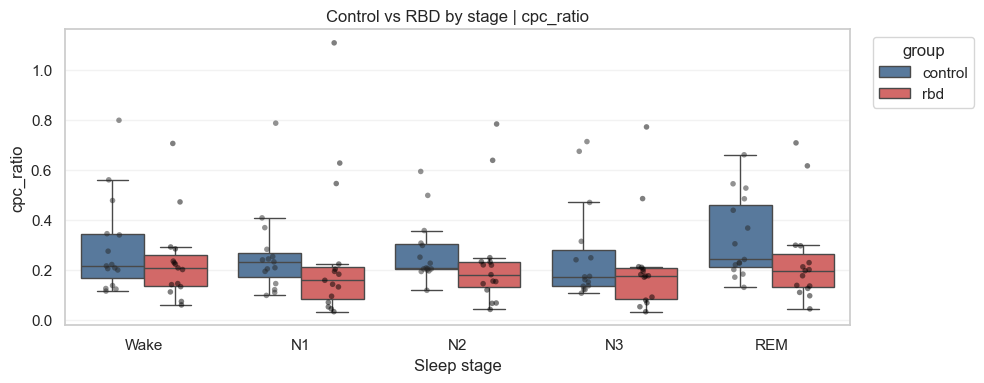


Stage-level comparison for hr_mean_bpm


,stage,metric,test,n_control,n_rbd,mean_control,mean_rbd,p_value,p_fdr_bh,effect_size
0,Wake,hr_mean_bpm,welch_t,15,15,74.2157,63.8082,0.0186,0.0418,0.9175
1,N1,hr_mean_bpm,welch_t,15,15,72.1216,62.6048,0.0360,0.0450,0.8081
2,N2,hr_mean_bpm,welch_t,15,15,69.7206,61.1320,0.0454,0.0454,0.7691
3,N3,hr_mean_bpm,welch_t,15,15,72.2601,60.9356,0.0203,0.0418,0.9029
4,REM,hr_mean_bpm,mann_whitney,15,15,69.4040,60.4237,0.0251,0.0418,-0.4844


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\statistics_stage_level_hr_mean_bpm.csv


C:\Users\carlo\AppData\Local\Temp\ipykernel_32980\2519840740.py:312: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=plot_df, x="stage", y=metric, hue="group", order=stage_order, hue_order=group_order, dodge=True, alpha=0.5, color="black", size=4, ax=ax)


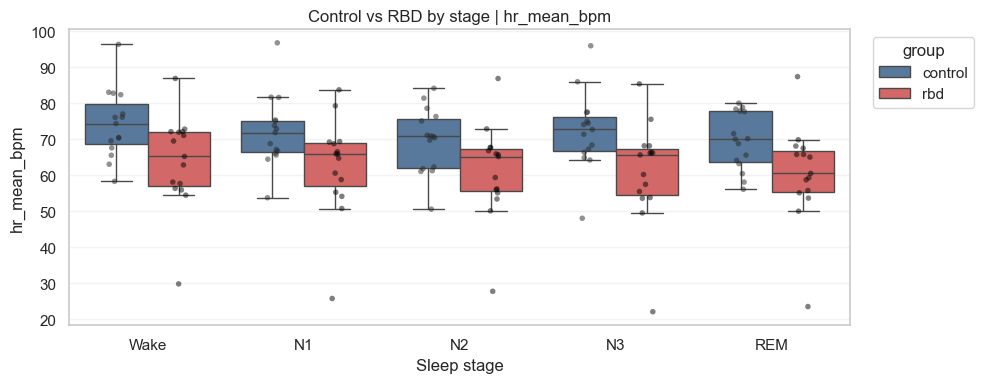

In [3]:
# Here each point is the mean of that stage within one patient.
stage_metrics = ["hep_30s", "delta_30s", "cpc_ratio", "hr_mean_bpm"]

for metric in stage_metrics:
    print(f"\nStage-level comparison for {metric}")
    stage_stats = stage_stats_table(stage_df, metric)
    display(stage_stats[["stage", "metric", "test", "n_control", "n_rbd", "mean_control", "mean_rbd", "p_value", "p_fdr_bh", "effect_size"]].round(4))

    stage_csv = results_dir / f"statistics_stage_level_{metric}.csv"
    stage_stats.to_csv(stage_csv, index=False)
    print(f"Saved: {stage_csv}")

    plot_stage_metric(stage_df, metric, title=f"Control vs RBD by stage | {metric}")
